# Notebook 03: dataset de regresión

Este notebook construye `df_regresion` para predecir `cantidad` por venta. Usa joins entre ventas, clientes, productos y tiendas, e incorpora variables de ingeniería disponibles antes del evento para evitar data leakage.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 140)

base_dir = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
data_dir = base_dir / 'datos'

print(f'Directorio base: {base_dir}')
print(f'Directorio de datos: {data_dir}')

Directorio base: c:\repos\Analitica_Datos_01\proyecto-andinaretail
Directorio de datos: c:\repos\Analitica_Datos_01\proyecto-andinaretail\datos


In [2]:
# Carga de tablas

df_ventas = pd.read_csv(data_dir / 'ventas.csv')
df_clientes = pd.read_csv(data_dir / 'clientes.csv')
df_productos = pd.read_csv(data_dir / 'productos.csv')
df_tiendas = pd.read_csv(data_dir / 'tiendas.csv')
df_inventario = pd.read_csv(data_dir / 'inventario.csv')

for nombre, df in {
    'ventas': df_ventas,
    'clientes': df_clientes,
    'productos': df_productos,
    'tiendas': df_tiendas,
    'inventario': df_inventario,
}.items():
    print(f'{nombre}: {df.shape}')
    display(df.head(2))

ventas: (250137, 11)


,id_venta,fecha,id_cliente,id_tienda,id_producto,cantidad,precio_unitario,descuento_pct,monto_total,canal,metodo_pago
0,1,2023-01-01,5051,4,426,1.0,41.26,16.50,34.45,Tienda Física,Tarjeta
1,2,2023-01-01,7791,2,249,1.0,28.05,4.09,26.90,Tienda Física,Efectivo


clientes: (15000, 9)


,id_cliente,nombre,edad,genero,ciudad,distrito,fecha_registro,canal_preferido,segmento
0,1,Jaqueline Barela Nazario,41.0,F,Arequipa,Paucarpata,2022-03-20,Tienda Física,Ocasional
1,2,Flavio Renato Corrales Zamudio,42.0,M,Trujillo,Mansiche,2020-05-16,Web,Nuevo


productos: (800, 8)


,id_producto,nombre,categoria,subcategoria,marca,precio_lista,costo_unitario,fecha_alta
0,1,Rexona Shampoo Casa,Cuidado Personal,Shampoo,Rexona,41.38,32.90,2020-03-14
1,2,Sapolio Limpiadores Mil,Limpieza,Limpiadores,Sapolio,32.46,21.15,2020-03-16


tiendas: (12, 7)


,id_tienda,nombre,ciudad,region,tipo,area_m2,fecha_apertura
0,1,AndinaRetail Lima Hipermercado 1,Lima,Lima,Hipermercado,6096.73,2017-03-05
1,2,AndinaRetail Lima Hipermercado 2,Lima,Lima,Hipermercado,9805.94,2021-07-09


inventario: (9600, 7)


,id_producto,id_tienda,stock,stock_minimo,stock_maximo,costo_almacenamiento,ultima_actualizacion
0,1,1,19.0,3.0,28.0,3.77,2025-12-23
1,1,2,25.0,5.0,37.0,3.88,2025-12-24


## Base del dataset

Se toma `ventas` como tabla base y se agregan atributos de clientes, productos y tiendas con `left join` para conservar todas las transacciones. Después se construyen variables históricas con `shift` y `cumsum` para garantizar que no se use información futura.

### Nota sobre inventario

La tabla `inventario` se carga para exploración, pero no se incorpora al dataset de regresión porque su snapshot está fechado al cierre de 2025 y no está alineado temporalmente con cada venta. Incluirla introduciría leakage y sesgos de disponibilidad futura.

In [3]:
# Construcción de la base de modelado con joins y features temporales

def buscar_directorio_datos(inicio: Path) -> Path:
    candidatos = [inicio, inicio.parent, inicio.parent.parent]
    for candidato in candidatos:
        if (candidato / 'datos').exists():
            return candidato
        if (candidato / 'proyecto-andinaretail' / 'datos').exists():
            return candidato / 'proyecto-andinaretail'
    raise FileNotFoundError('No se encontró el directorio de datos.')

base_dir = buscar_directorio_datos(Path.cwd())
data_dir = base_dir / 'datos'

ventas = df_ventas.copy()
clientes = df_clientes[[
    'id_cliente', 'edad', 'genero', 'ciudad', 'distrito', 'fecha_registro', 'canal_preferido', 'segmento'
]].copy()
productos = df_productos[[
    'id_producto', 'categoria', 'subcategoria', 'marca', 'precio_lista', 'costo_unitario', 'fecha_alta'
]].copy()
tiendas = df_tiendas[[
    'id_tienda', 'ciudad', 'region', 'tipo', 'area_m2', 'fecha_apertura'
]].copy()

clientes = clientes.rename(columns={
    'ciudad': 'ciudad_cliente',
    'distrito': 'distrito_cliente',
    'fecha_registro': 'fecha_registro_cliente'
})
productos = productos.rename(columns={'fecha_alta': 'fecha_alta_producto'})
tiendas = tiendas.rename(columns={
    'ciudad': 'ciudad_tienda',
    'region': 'region_tienda',
    'tipo': 'tipo_tienda',
    'fecha_apertura': 'fecha_apertura_tienda'
})

ventas['fecha'] = pd.to_datetime(ventas['fecha'])
clientes['fecha_registro_cliente'] = pd.to_datetime(clientes['fecha_registro_cliente'])
productos['fecha_alta_producto'] = pd.to_datetime(productos['fecha_alta_producto'])
tiendas['fecha_apertura_tienda'] = pd.to_datetime(tiendas['fecha_apertura_tienda'])

# El orden temporal es clave para construir variables históricas sin usar información futura.
ventas = ventas.sort_values(['id_cliente', 'fecha', 'id_venta']).reset_index(drop=True)

df_base = (
    ventas
    .merge(clientes, on='id_cliente', how='left')
    .merge(productos, on='id_producto', how='left')
    .merge(tiendas, on='id_tienda', how='left')
)

# Variables temporales conocidas al momento de la venta
df_base['anio_venta'] = df_base['fecha'].dt.year
df_base['mes_venta'] = df_base['fecha'].dt.month
df_base['trimestre_venta'] = df_base['fecha'].dt.quarter
df_base['dia_semana_venta'] = df_base['fecha'].dt.dayofweek
df_base['es_fin_de_semana'] = (df_base['dia_semana_venta'] >= 5).astype(int)
df_base['es_temporada_alta'] = df_base['mes_venta'].isin([7, 12]).astype(int)
df_base['es_trujillo_post_q2_2025'] = ((df_base['ciudad_tienda'] == 'Trujillo') & (df_base['fecha'] >= pd.Timestamp('2025-04-01'))).astype(int)

# Antiguedad calculada a partir de fechas ya observables en cada venta
df_base['antiguedad_cliente_dias'] = (df_base['fecha'] - df_base['fecha_registro_cliente']).dt.days.clip(lower=0)
df_base['antiguedad_producto_dias'] = (df_base['fecha'] - df_base['fecha_alta_producto']).dt.days.clip(lower=0)
df_base['antiguedad_tienda_dias'] = (df_base['fecha'] - df_base['fecha_apertura_tienda']).dt.days.clip(lower=0)

df_base['canal_digital'] = df_base['canal'].isin(['Web', 'App']).astype(int)
df_base['monto_historial'] = df_base['monto_total'].fillna(0)

grupo_cliente = df_base.groupby('id_cliente', sort=False)
df_base['frecuencia_previas'] = grupo_cliente.cumcount()
df_base['gasto_acumulado_previo'] = grupo_cliente['monto_historial'].transform(lambda s: s.shift().cumsum()).fillna(0)
df_base['fecha_compra_anterior'] = grupo_cliente['fecha'].shift()
df_base['recencia_prev_dias'] = (df_base['fecha'] - df_base['fecha_compra_anterior']).dt.days.fillna(9999)
df_base['compras_digitales_previas'] = grupo_cliente['canal_digital'].transform(lambda s: s.shift().cumsum()).fillna(0)
df_base['ticket_promedio_previo'] = np.where(
    df_base['frecuencia_previas'] > 0,
    df_base['gasto_acumulado_previo'] / df_base['frecuencia_previas'],
    0
)
df_base['proporcion_digital_previa'] = np.where(
    df_base['frecuencia_previas'] > 0,
    df_base['compras_digitales_previas'] / df_base['frecuencia_previas'],
    0
)

print('Base unificada:')
print(df_base.shape)
display(df_base.head(3))

Base unificada:
(250137, 48)


,id_venta,fecha,id_cliente,id_tienda,id_producto,cantidad,precio_unitario,descuento_pct,monto_total,canal,metodo_pago,edad,genero,ciudad_cliente,distrito_cliente,fecha_registro_cliente,canal_preferido,segmento,categoria,subcategoria,marca,precio_lista,costo_unitario,fecha_alta_producto,ciudad_tienda,region_tienda,tipo_tienda,area_m2,fecha_apertura_tienda,anio_venta,mes_venta,trimestre_venta,dia_semana_venta,es_fin_de_semana,es_temporada_alta,es_trujillo_post_q2_2025,antiguedad_cliente_dias,antiguedad_producto_dias,antiguedad_tienda_dias,canal_digital,monto_historial,frecuencia_previas,gasto_acumulado_previo,fecha_compra_anterior,recencia_prev_dias,compras_digitales_previas,ticket_promedio_previo,proporcion_digital_previa
0,5155,2023-01-26,1,12,129,1.0,25.79,10.16,23.17,App,Yape,41.0,F,Arequipa,Paucarpata,2022-03-20,Tienda Física,Ocasional,Bebidas,Cervezas,Cusqueña,24.57,18.03,2020-08-06,Piura,Piura,Virtual,48.34,2015-10-20,2023,1,1,3,0,0,0,312.0,903,2655,1,23.17,0,0.00,NaT,9999.0,0.0,0.00,0.0
1,8399,2023-02-11,1,10,180,1.0,23.52,18.86,19.09,Tienda Física,Plin,41.0,F,Arequipa,Paucarpata,2022-03-20,Tienda Física,Ocasional,Bebidas,Licores,Red Bull,23.22,15.58,2022-06-26,Cusco,Cusco,Supermercado,1036.13,2020-02-06,2023,2,1,5,1,0,0,328.0,230,1101,0,19.09,1,23.17,2023-01-26,16.0,1.0,23.17,1.0
2,26982,2023-05-12,1,4,269,3.0,28.91,21.57,68.03,Tienda Física,Efectivo,41.0,F,Arequipa,Paucarpata,2022-03-20,Tienda Física,Ocasional,Limpieza,Trapeadores,Glade,28.67,17.54,2022-08-17,Lima,Lima,Supermercado,2823.43,2022-07-28,2023,5,2,4,0,0,0,418.0,268,288,0,68.03,2,42.26,2023-02-11,90.0,1.0,21.13,0.5


In [4]:
# Selección final, imputación y prevención de leakage

columnas_finales = [
    'cantidad',
    'anio_venta', 'mes_venta', 'trimestre_venta', 'dia_semana_venta', 'es_fin_de_semana', 'es_temporada_alta', 'es_trujillo_post_q2_2025',
    'categoria', 'subcategoria', 'marca', 'precio_lista', 'costo_unitario', 'antiguedad_producto_dias',
    'ciudad_tienda', 'region_tienda', 'tipo_tienda', 'area_m2', 'antiguedad_tienda_dias',
    'edad', 'genero', 'ciudad_cliente', 'distrito_cliente', 'canal_preferido', 'segmento', 'antiguedad_cliente_dias',
    'frecuencia_previas', 'gasto_acumulado_previo', 'ticket_promedio_previo', 'recencia_prev_dias', 'proporcion_digital_previa'
]

# No incluir variables que exponen el resultado de la venta o identificadores directos.
columnas_prohibidas = ['id_venta', 'fecha', 'id_cliente', 'id_tienda', 'id_producto', 'precio_unitario', 'descuento_pct', 'monto_total', 'fecha_registro_cliente', 'fecha_alta_producto', 'fecha_apertura_tienda']
presentes_prohibidas = [col for col in columnas_prohibidas if col in df_base.columns]
print('Columnas prohibidas presentes en la base (no se usarán como features):')
print(presentes_prohibidas)

df_regresion = df_base[columnas_finales].copy()
df_regresion = df_regresion.dropna(subset=['cantidad']).reset_index(drop=True)

columnas_numericas = df_regresion.select_dtypes(include=['number']).columns.tolist()
columnas_categoricas = df_regresion.select_dtypes(include=['object']).columns.tolist()

for columna in columnas_numericas:
    if df_regresion[columna].isna().any():
        df_regresion[columna] = df_regresion[columna].fillna(df_regresion[columna].median())

for columna in columnas_categoricas:
    if df_regresion[columna].isna().any():
        moda = df_regresion[columna].mode(dropna=True)
        relleno = moda.iloc[0] if not moda.empty else 'Desconocido'
        df_regresion[columna] = df_regresion[columna].fillna(relleno)

assert 'monto_total' not in df_regresion.columns
assert 'descuento_pct' not in df_regresion.columns
assert 'precio_unitario' not in df_regresion.columns
assert 'id_venta' not in df_regresion.columns

print('df_regresion listo:')
print(df_regresion.shape)
print(df_regresion.columns.tolist())
display(df_regresion.head())

ruta_salida = data_dir / 'df_regresion.csv'
df_regresion.to_csv(ruta_salida, index=False, encoding='utf-8')
print(f'Dataset exportado en: {ruta_salida}')

Columnas prohibidas presentes en la base (no se usarán como features):
['id_venta', 'fecha', 'id_cliente', 'id_tienda', 'id_producto', 'precio_unitario', 'descuento_pct', 'monto_total', 'fecha_registro_cliente', 'fecha_alta_producto', 'fecha_apertura_tienda']
df_regresion listo:
(249472, 31)
['cantidad', 'anio_venta', 'mes_venta', 'trimestre_venta', 'dia_semana_venta', 'es_fin_de_semana', 'es_temporada_alta', 'es_trujillo_post_q2_2025', 'categoria', 'subcategoria', 'marca', 'precio_lista', 'costo_unitario', 'antiguedad_producto_dias', 'ciudad_tienda', 'region_tienda', 'tipo_tienda', 'area_m2', 'antiguedad_tienda_dias', 'edad', 'genero', 'ciudad_cliente', 'distrito_cliente', 'canal_preferido', 'segmento', 'antiguedad_cliente_dias', 'frecuencia_previas', 'gasto_acumulado_previo', 'ticket_promedio_previo', 'recencia_prev_dias', 'proporcion_digital_previa']


,cantidad,anio_venta,mes_venta,trimestre_venta,dia_semana_venta,es_fin_de_semana,es_temporada_alta,es_trujillo_post_q2_2025,categoria,subcategoria,marca,precio_lista,costo_unitario,antiguedad_producto_dias,ciudad_tienda,region_tienda,tipo_tienda,area_m2,antiguedad_tienda_dias,edad,genero,ciudad_cliente,distrito_cliente,canal_preferido,segmento,antiguedad_cliente_dias,frecuencia_previas,gasto_acumulado_previo,ticket_promedio_previo,recencia_prev_dias,proporcion_digital_previa
0,1.0,2023,1,1,3,0,0,0,Bebidas,Cervezas,Cusqueña,24.57,18.03,903,Piura,Piura,Virtual,48.34,2655,41.0,F,Arequipa,Paucarpata,Tienda Física,Ocasional,312.0,0,0.00,0.000000,9999.0,0.000000
1,1.0,2023,2,1,5,1,0,0,Bebidas,Licores,Red Bull,23.22,15.58,230,Cusco,Cusco,Supermercado,1036.13,1101,41.0,F,Arequipa,Paucarpata,Tienda Física,Ocasional,328.0,1,23.17,23.170000,16.0,1.000000
2,3.0,2023,5,2,4,0,0,0,Limpieza,Trapeadores,Glade,28.67,17.54,268,Lima,Lima,Supermercado,2823.43,288,41.0,F,Arequipa,Paucarpata,Tienda Física,Ocasional,418.0,2,42.26,21.130000,90.0,0.500000
3,1.0,2023,6,2,2,0,0,0,Hogar,Textil Hogar,Fantasía,125.39,87.99,209,Lima,Lima,Hipermercado,9805.94,705,41.0,F,Arequipa,Paucarpata,Tienda Física,Ocasional,451.0,3,110.29,36.763333,33.0,0.333333
4,1.0,2023,6,2,2,0,0,0,Hogar,Decoración,Ripley Home,178.87,108.27,281,Piura,Piura,Virtual,48.34,2801,41.0,F,Arequipa,Paucarpata,Tienda Física,Ocasional,458.0,4,216.94,54.235000,7.0,0.250000


Dataset exportado en: c:\repos\Analitica_Datos_01\proyecto-andinaretail\datos\df_regresion.csv


## Validación final

El dataset queda preparado para entrenar modelos en una siguiente etapa. En este punto no se ajusta ningún algoritmo; solo se construye `df_regresion` con ingeniería de variables y controles de leakage.

## Preparación para Machine Learning

En esta sección se separa la variable objetivo, se identifican variables numéricas y categóricas, y se arma un pipeline de preprocesamiento listo para entrenamiento. No se ajusta ningún modelo todavía.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Separación de variables
X = df_regresion.drop(columns=['cantidad']).copy()
y = df_regresion['cantidad'].copy()

# Identificación de tipos de variables
columnas_numericas_ml = X.select_dtypes(include=['number']).columns.tolist()
columnas_categoricas_ml = X.select_dtypes(include=['object']).columns.tolist()

print('Variables numéricas:')
print(columnas_numericas_ml)
print('\nVariables categóricas:')
print(columnas_categoricas_ml)

# Partición entrenamiento / prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Pipelines de preprocesamiento
preprocesamiento_numerico = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='median')),
    ('escalador', StandardScaler())
])

preprocesamiento_categorico = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('numericas', preprocesamiento_numerico, columnas_numericas_ml),
        ('categoricas', preprocesamiento_categorico, columnas_categoricas_ml)
    ],
    remainder='drop'
)

pipeline_preprocesamiento = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test: {y_test.shape}')
print('\nPipeline de preprocesamiento creado correctamente.')

Variables numéricas:
['anio_venta', 'mes_venta', 'trimestre_venta', 'dia_semana_venta', 'es_fin_de_semana', 'es_temporada_alta', 'es_trujillo_post_q2_2025', 'precio_lista', 'costo_unitario', 'antiguedad_producto_dias', 'area_m2', 'antiguedad_tienda_dias', 'edad', 'antiguedad_cliente_dias', 'frecuencia_previas', 'gasto_acumulado_previo', 'ticket_promedio_previo', 'recencia_prev_dias', 'proporcion_digital_previa']

Variables categóricas:
['categoria', 'subcategoria', 'marca', 'ciudad_tienda', 'region_tienda', 'tipo_tienda', 'genero', 'ciudad_cliente', 'distrito_cliente', 'canal_preferido', 'segmento']
X_train: (199577, 30)
X_test: (49895, 30)
y_train: (199577,)
y_test: (49895,)

Pipeline de preprocesamiento creado correctamente.


### Estado final

`df_regresion` ya quedó preparado para pasar a modelado supervisado. En esta etapa solo se definieron los datos de entrada, la partición de entrenamiento y prueba, y el preprocesamiento; no se entrenó ningún algoritmo.

## Entrenamiento y comparación de modelos

A partir del preprocesamiento ya definido, se entrenan dos modelos de regresión: `LinearRegression` y `RandomForestRegressor`. La comparación usa MAE, RMSE y R² sobre el conjunto de prueba.

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Aplicar el pipeline de preprocesamiento ya creado
X_train_preparado = pipeline_preprocesamiento.fit_transform(X_train)
X_test_preparado = pipeline_preprocesamiento.transform(X_test)

# Convertir a denso solo si el resultado viene en formato disperso
if hasattr(X_train_preparado, 'toarray'):
    X_train_preparado = X_train_preparado.toarray()
    X_test_preparado = X_test_preparado.toarray()

# Entrenamiento de modelos solicitados
modelo_lr = LinearRegression()
modelo_lr.fit(X_train_preparado, y_train)
pred_lr = modelo_lr.predict(X_test_preparado)

modelo_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
modelo_rf.fit(X_train_preparado, y_train)
pred_rf = modelo_rf.predict(X_test_preparado)

# Evaluación
resultados_modelos = pd.DataFrame([
    {
        'modelo': 'LinearRegression',
        'MAE': mean_absolute_error(y_test, pred_lr),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred_lr)),
        'R2': r2_score(y_test, pred_lr)
    },
    {
        'modelo': 'RandomForestRegressor',
        'MAE': mean_absolute_error(y_test, pred_rf),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred_rf)),
        'R2': r2_score(y_test, pred_rf)
    }
]).sort_values(by=['R2', 'RMSE'], ascending=[False, True]).reset_index(drop=True)

mejor_modelo = resultados_modelos.iloc[0]['modelo']

print('Tabla comparativa de modelos:')
display(resultados_modelos)
print(f'\nMejor modelo seleccionado: {mejor_modelo}')

Tabla comparativa de modelos:


,modelo,MAE,RMSE,R2
0,LinearRegression,1.049210,1.717669,0.078430
1,RandomForestRegressor,1.081871,1.739630,0.054715



Mejor modelo seleccionado: LinearRegression


### Resultado

La comparación queda lista para continuar con el modelo ganador en una siguiente etapa, sin agregar más algoritmos ni alterar el pipeline de preparación.

## Optimización del mejor modelo

Se optimiza únicamente el modelo ganador actual (`LinearRegression`) con `RandomizedSearchCV`, usando 5 folds y `random_state=42`. Luego se compara el desempeño antes y después de la búsqueda.

In [8]:
from sklearn.model_selection import RandomizedSearchCV

# El mejor modelo previo fue LinearRegression, así que solo se optimiza ese estimador.
modelo_base = LinearRegression()

param_distributions_lr = {
    'fit_intercept': [True, False],
    'positive': [False, True],
    'copy_X': [True, False]
}

busqueda_lr = RandomizedSearchCV(
    estimator=modelo_base,
    param_distributions=param_distributions_lr,
    n_iter=6,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    refit=True
)

busqueda_lr.fit(X_train_preparado, y_train)

modelo_lr_optimizado = busqueda_lr.best_estimator_
pred_lr_optimizado = modelo_lr_optimizado.predict(X_test_preparado)

comparacion_lr = pd.DataFrame([
    {
        'etapa': 'Antes',
        'modelo': 'LinearRegression',
        'MAE': mean_absolute_error(y_test, pred_lr),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred_lr)),
        'R2': r2_score(y_test, pred_lr)
    },
    {
        'etapa': 'Después',
        'modelo': 'LinearRegression optimizado',
        'MAE': mean_absolute_error(y_test, pred_lr_optimizado),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred_lr_optimizado)),
        'R2': r2_score(y_test, pred_lr_optimizado)
    }
])

comparacion_lr['mejora_RMSE'] = comparacion_lr.loc[0, 'RMSE'] - comparacion_lr['RMSE']
comparacion_lr['mejora_R2'] = comparacion_lr['R2'] - comparacion_lr.loc[0, 'R2']

print('Mejores hiperparámetros encontrados:')
print(busqueda_lr.best_params_)
print(f"\nMejor RMSE en validación cruzada: {abs(busqueda_lr.best_score_):.6f}")
print('\nComparación antes y después:')
display(comparacion_lr)

Mejores hiperparámetros encontrados:
{'positive': True, 'fit_intercept': False, 'copy_X': False}

Mejor RMSE en validación cruzada: 1.625249

Comparación antes y después:


,etapa,modelo,MAE,RMSE,R2,mejora_RMSE,mejora_R2
0,Antes,LinearRegression,1.04921,1.717669,0.078430,0.000000,0.000000
1,Después,LinearRegression optimizado,1.04910,1.717598,0.078506,0.000071,0.000077


## Interpretación del mejor modelo

Se analiza el modelo de regresión optimizado para identificar las variables más influyentes. Para una regresión lineal, la importancia se obtiene a partir de los coeficientes. Si `shap` está disponible, también se genera una explicación SHAP.

Top 15 variables más influyentes por coeficientes:


,variable,coeficiente,importancia_absoluta
98,marca_Valle,2.867753,2.867753
69,marca_Costeño,2.842500,2.842500
71,marca_Doña Clara,2.821605,2.821605
87,marca_Primor,2.817954,2.817954
96,marca_Tondero,2.805783,2.805783
79,marca_Nicolini,2.798338,2.798338
89,marca_Red Bull,1.972056,1.972056
93,marca_San Mateo,1.941122,1.941122
67,marca_Coca-Cola,1.927810,1.927810
70,marca_Cusqueña,1.910907,1.910907


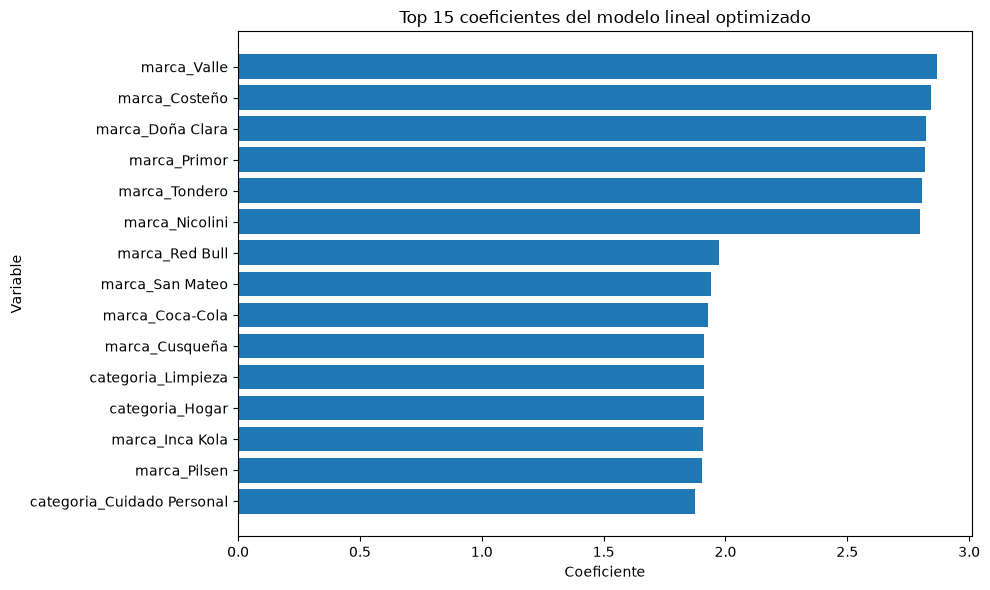

SHAP no está instalado en este entorno. Se mantiene la interpretación por coeficientes, que sí aplica para este modelo lineal.


In [ ]:
import matplotlib.pyplot as plt

# Recuperar nombres de variables luego del preprocesamiento
nombres_features_numericas = columnas_numericas_ml
nombres_features_categoricas = list(
    pipeline_preprocesamiento.named_steps['preprocessor']
    .named_transformers_['categoricas']
    .named_steps['onehot']
    .get_feature_names_out(columnas_categoricas_ml)
)
nombres_features_transformadas = nombres_features_numericas + nombres_features_categoricas

# Importancia por coeficientes del modelo lineal optimizado
coeficientes = modelo_lr_optimizado.coef_
importancia_coeficientes = pd.DataFrame({
    'variable': nombres_features_transformadas,
    'coeficiente': coeficientes,
    'importancia_absoluta': np.abs(coeficientes)
}).sort_values('importancia_absoluta', ascending=False)

print('Top 15 variables más influyentes por coeficientes:')
display(importancia_coeficientes.head(15))

plt.figure(figsize=(10, 6))
orden_top = importancia_coeficientes.head(15).sort_values('importancia_absoluta', ascending=True)
plt.barh(orden_top['variable'], orden_top['coeficiente'])
plt.title('Top 15 coeficientes del modelo lineal optimizado')
plt.xlabel('Coeficiente')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

# SHAP si está disponible
try:
    shap = __import__('shap')

    shap.initjs()
    shap_explainer = shap.LinearExplainer(modelo_lr_optimizado, X_train_preparado, feature_perturbation='interventional')
    shap_values = shap_explainer.shap_values(X_test_preparado)

    shap_importancia = pd.DataFrame({
        'variable': nombres_features_transformadas,
        'shap_abs_mean': np.abs(shap_values).mean(axis=0)
    }).sort_values('shap_abs_mean', ascending=False)

    print('Top 15 variables más influyentes por SHAP:')
    display(shap_importancia.head(15))

    plt.figure(figsize=(10, 6))
    orden_shap = shap_importancia.head(15).sort_values('shap_abs_mean', ascending=True)
    plt.barh(orden_shap['variable'], orden_shap['shap_abs_mean'])
    plt.title('Top 15 variables por importancia SHAP')
    plt.xlabel('SHAP medio absoluto')
    plt.ylabel('Variable')
    plt.tight_layout()
    plt.show()

    resumen_shap = shap.Explainer(modelo_lr_optimizado, X_train_preparado)
    shap.summary_plot(shap_values, X_test_preparado, feature_names=nombres_features_transformadas, show=True)
except ImportError:
    print('SHAP no está instalado en este entorno. Se mantiene la interpretación por coeficientes, que sí aplica para este modelo lineal.')

### Lectura de resultados

En un modelo lineal, un coeficiente positivo indica que al aumentar esa variable también tiende a aumentar `cantidad`, mientras que un coeficiente negativo sugiere el efecto contrario. Si SHAP está disponible, su ranking debe ser consistente con esta lectura global y ayuda a confirmar la influencia relativa de las variables.

## Dataset de clasificación

Se construye `df_clasificacion` para predecir `cliente_inactivo`, donde `1` indica que el cliente no tuvo compras en los últimos 90 días del período y `0` indica que sigue activo. Todas las agregaciones se calculan con historial anterior a la fecha de corte para evitar data leakage.

In [11]:
# Construcción del dataset de clasificación con corte temporal

ventas_total = df_ventas.copy()
ventas_total['fecha'] = pd.to_datetime(ventas_total['fecha'])

fecha_maxima = ventas_total['fecha'].max()
fecha_corte = fecha_maxima - pd.Timedelta(days=90)

ventas_hist = ventas_total[ventas_total['fecha'] <= fecha_corte].copy()

# Agregados históricos por cliente usando solo información disponible antes del corte
agregados_hist = ventas_hist.groupby('id_cliente').agg(
    frecuencia_compra=('id_venta', 'count'),
    gasto_total=('monto_total', 'sum'),
    ticket_promedio=('monto_total', 'mean'),
    ultima_compra=('fecha', 'max'),
    compras_digitales=('canal', lambda s: s.isin(['Web', 'App']).sum())
).reset_index()

agregados_hist['dias_inactividad'] = (fecha_corte - agregados_hist['ultima_compra']).dt.days
agregados_hist['porcentaje_digital'] = np.where(
    agregados_hist['frecuencia_compra'] > 0,
    agregados_hist['compras_digitales'] / agregados_hist['frecuencia_compra'],
    0
)

# Canal predominante calculado solo con el historial permitido
canal_hist = (
    ventas_hist.assign(canal_digital=ventas_hist['canal'].isin(['Web', 'App']))
    .groupby('id_cliente')['canal']
    .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else 'Sin compra')
    .reset_index()
    .rename(columns={'canal': 'canal_historico_principal'})
)

# Etiqueta de inactividad: 1 si el último pedido quedó fuera de la ventana de los últimos 90 días
ultima_compra_total = ventas_total.groupby('id_cliente')['fecha'].max().reset_index().rename(columns={'fecha': 'ultima_compra_total'})

df_clasificacion = (
    df_clientes[['id_cliente', 'edad', 'genero', 'ciudad', 'distrito', 'fecha_registro', 'canal_preferido', 'segmento']]
    .rename(columns={
        'ciudad': 'ciudad_cliente',
        'distrito': 'distrito_cliente',
        'fecha_registro': 'fecha_registro_cliente',
        'canal_preferido': 'canal'
    })
    .merge(agregados_hist, on='id_cliente', how='left')
    .merge(canal_hist, on='id_cliente', how='left')
    .merge(ultima_compra_total, on='id_cliente', how='left')
)

df_clasificacion['cliente_inactivo'] = np.where(
    df_clasificacion['ultima_compra_total'].isna() | (df_clasificacion['ultima_compra_total'] <= fecha_corte),
    1,
    0
)

# Clientes sin compras históricas se consideran inactivos y quedan con agregados en cero
columnas_cero = ['frecuencia_compra', 'gasto_total', 'ticket_promedio', 'compras_digitales', 'porcentaje_digital']
for columna in columnas_cero:
    df_clasificacion[columna] = df_clasificacion[columna].fillna(0)

df_clasificacion['ultima_compra'] = df_clasificacion['ultima_compra'].fillna(pd.NaT)
df_clasificacion['dias_inactividad'] = np.where(
    df_clasificacion['dias_inactividad'].isna(),
    (fecha_corte - pd.to_datetime(df_clasificacion['fecha_registro_cliente'])).dt.days,
    df_clasificacion['dias_inactividad']
)

# Limpieza para dejar un dataset descriptivo y listo para modelado posterior
df_clasificacion = df_clasificacion[[
    'id_cliente', 'cliente_inactivo', 'frecuencia_compra', 'gasto_total', 'ticket_promedio', 'ultima_compra', 'dias_inactividad',
    'canal', 'canal_historico_principal', 'segmento', 'edad', 'genero', 'ciudad_cliente', 'distrito_cliente', 'fecha_registro_cliente'
]].copy()

print('Fecha máxima de ventas:', fecha_maxima.date())
print('Fecha de corte para inactividad:', fecha_corte.date())
print('Distribución del target:')
display(df_clasificacion['cliente_inactivo'].value_counts().rename_axis('cliente_inactivo').reset_index(name='conteo'))
print('\ndf_clasificacion listo:')
print(df_clasificacion.shape)
display(df_clasificacion.head())

ruta_salida_clasificacion = data_dir / 'df_clasificacion.csv'
df_clasificacion.to_csv(ruta_salida_clasificacion, index=False, encoding='utf-8')
print(f'Dataset exportado en: {ruta_salida_clasificacion}')

Fecha máxima de ventas: 2025-12-31
Fecha de corte para inactividad: 2025-10-02
Distribución del target:


,cliente_inactivo,conteo
0,0,11952
1,1,3048



df_clasificacion listo:
(15000, 15)


,id_cliente,cliente_inactivo,frecuencia_compra,gasto_total,ticket_promedio,ultima_compra,dias_inactividad,canal,canal_historico_principal,segmento,edad,genero,ciudad_cliente,distrito_cliente,fecha_registro_cliente
0,1,0,20,3272.22000,163.611000,2025-09-22,10.0,Tienda Física,Tienda Física,Ocasional,41.0,F,Arequipa,Paucarpata,2022-03-20
1,2,1,17,6373.38000,374.904706,2025-07-20,74.0,Web,Tienda Física,Nuevo,42.0,M,Trujillo,Mansiche,2020-05-16
2,3,0,11,4278.36000,388.941818,2025-09-08,24.0,Web,Tienda Física,Regular,35.0,F,Lima,Jesus María,2021-12-30
3,4,0,16,3206.19072,200.386920,2025-07-25,69.0,App,Tienda Física,Regular,24.0,M,Cusco,Santiago,2021-11-29
4,5,0,20,5492.62000,274.631000,2025-04-03,182.0,Tienda Física,Tienda Física,Regular,18.0,F,Lima,San Miguel,2021-12-17


Dataset exportado en: c:\repos\Analitica_Datos_01\proyecto-andinaretail\datos\df_clasificacion.csv


### Validación de leakage

El target se define con la última compra real del período completo, pero las variables predictoras se construyen solo con compras anteriores a la fecha de corte. De esta forma, `frecuencia_compra`, `gasto_total`, `ticket_promedio`, `ultima_compra`, `dias_inactividad`, `canal`, `segmento` y las variables demográficas quedan libres de fuga temporal para el entrenamiento posterior.